In [1]:
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# seed = 62786278

# np.random.seed(seed)
# np.random.seed(seed)
# torch.manual_seed(seed)

In [2]:
pd.set_option('mode.chained_assignment', None)

## DATA PREP

In [3]:
df = pd.read_parquet("../../novus/matchingnemo/scratch/ampnet_data/Portland/w1.parquet", engine = "pyarrow")

In [4]:
df.columns = df.columns.str.lower()
df.head()

,build_id,occ_cls,prim_occ,sqmeters,sqfeet,censuscode,uuid,safegraph_place_id,date_range_start,t,visits
0,2350927,Unclassified,Unclassified,62.070034,668.115662,41025960200,{066c74de-14c5-4655-b450-2d24f75852bd},nan,NaT,NaN,NaN
1,2350928,Unclassified,Unclassified,67.231216,723.670105,41025960200,{38b01679-552a-4a84-936b-58811561c36b},nan,NaT,NaN,NaN
2,2350935,Agriculture,Agriculture,235.860687,2538.780762,41025960200,{e8501fa8-b19b-440b-8bf8-f90fd90f08ac},nan,NaT,NaN,NaN
3,2350993,Unclassified,Unclassified,308.850983,3324.441162,41025960200,{5f540e3d-e257-4371-a60e-f8b0bec87ec6},nan,NaT,NaN,NaN
4,2351003,Agriculture,Agriculture,61.829311,665.524536,41025960200,{c4127cbc-5d80-4aee-b7a3-c95e61223f13},nan,NaT,NaN,NaN


In [5]:
visits_data = df[['build_id', 't', 'visits']].drop_duplicates(subset = ['build_id', 't']).dropna()
visits_data = visits_data.pivot(index = 'build_id', values = 'visits', columns = 't')


(array([651168., 113400.,  66024.,  23688.,  26880.,   6552.,   5040.,
             0.,   3360.,  14616.]),
 array([ 2. ,  4.1,  6.2,  8.3, 10.4, 12.5, 14.6, 16.7, 18.8, 20.9, 23. ]),
 <BarContainer object of 10 artists>)

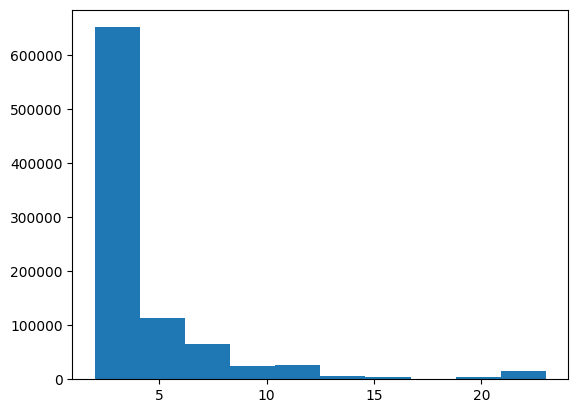

In [38]:
df['duplicate_count'] = (
    df.groupby(['build_id', 't', 'date_range_start'])['build_id']
      .transform('size')
)
plt.hist(df[df['duplicate_count']>1]['duplicate_count'])

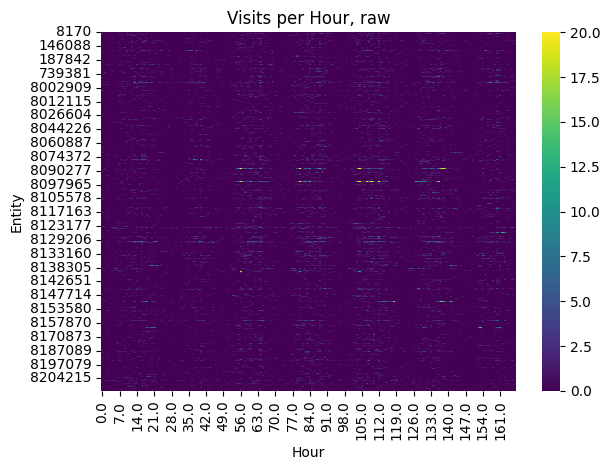

In [7]:

# Heatmap of raw data
# plt.figure(figsize=(12, 6))
sns.heatmap(visits_data, cmap="viridis", cbar=True, vmax = 20)

plt.xlabel("Hour")
plt.ylabel("Entity")
plt.title("Visits per Hour, raw")
plt.tight_layout()
plt.show()

In [8]:
dat = df[df['safegraph_place_id'] != 'nan']  # training set
dat = dat.dropna(subset = 't')

dat["hour_of_week"] = dat["t"] #t
dat["sqmeters"] = pd.to_numeric(dat["sqmeters"], errors="coerce")
dat["hour_d"] = dat["hour_of_week"] % 24  # 0-23
dat["sin_hod"] = np.sin(2 * np.pi * dat["hour_d"] / 24)
dat["cos_hod"] = np.cos(2 * np.pi * dat["hour_d"] / 24)


dat["day_w"] = dat["hour_of_week"] // 24  # 0-6
dat["sin_dow"] = np.sin(2 * np.pi * dat["day_w"] / 7)
dat["cos_dow"] = np.cos(2 * np.pi * dat["day_w"] / 7)


dat["sqmeters_scaled"] = dat["sqmeters"] / dat["sqmeters"].max()
dat["log_sqmeters"] = np.log(dat["sqmeters"])

dat["sq_q"] = pd.qcut(dat["sqmeters_scaled"], 4, labels=False)

dat["x_prim_occ"] = dat["prim_occ"].astype("category").cat.codes

In [9]:
dat.head()

,build_id,occ_cls,prim_occ,sqmeters,sqfeet,censuscode,uuid,safegraph_place_id,date_range_start,t,...,hour_d,sin_hod,cos_hod,day_w,sin_dow,cos_dow,sqmeters_scaled,log_sqmeters,sq_q,x_prim_occ
157694,678266,Education,Pre-K - 12 Schools,872.624207,9392.839844,41051009903,{37403d88-1494-43d3-8947-9d8300825241},sg:ee72a81f6547452291503c55f94f270d,2018-12-31 08:00:00,0.0,...,0.0,0.000000,1.000000,0.0,0.0,1.0,0.007383,6.771505,1,16
157695,678266,Education,Pre-K - 12 Schools,872.624207,9392.839844,41051009903,{37403d88-1494-43d3-8947-9d8300825241},sg:ee72a81f6547452291503c55f94f270d,2018-12-31 08:00:00,1.0,...,1.0,0.258819,0.965926,0.0,0.0,1.0,0.007383,6.771505,1,16
157696,678266,Education,Pre-K - 12 Schools,872.624207,9392.839844,41051009903,{37403d88-1494-43d3-8947-9d8300825241},sg:ee72a81f6547452291503c55f94f270d,2018-12-31 08:00:00,2.0,...,2.0,0.500000,0.866025,0.0,0.0,1.0,0.007383,6.771505,1,16
157697,678266,Education,Pre-K - 12 Schools,872.624207,9392.839844,41051009903,{37403d88-1494-43d3-8947-9d8300825241},sg:ee72a81f6547452291503c55f94f270d,2018-12-31 08:00:00,3.0,...,3.0,0.707107,0.707107,0.0,0.0,1.0,0.007383,6.771505,1,16
157698,678266,Education,Pre-K - 12 Schools,872.624207,9392.839844,41051009903,{37403d88-1494-43d3-8947-9d8300825241},sg:ee72a81f6547452291503c55f94f270d,2018-12-31 08:00:00,4.0,...,4.0,0.866025,0.500000,0.0,0.0,1.0,0.007383,6.771505,1,16


In [10]:
n_cats = len(dat["prim_occ"].unique())

In [11]:
# split into train and test set, random building x time points

# from sklearn.model_selection import train_test_split
# tr, test, y_tr, y_test = train_test_split(
#     dat.drop('visits', axis = 1), dat['visits'], test_size=0.2, random_state=42)

# Hold out 10% of buildings
builds = dat["build_id"].unique()
rng = np.random.default_rng()
builds = rng.choice(builds, len(builds) // 10)

mask = dat["build_id"].isin(builds)
tr = dat[~mask].drop("visits", axis=1)
test = dat[mask].drop("visits", axis=1)

y_tr = dat[~mask]["visits"]
y_test = dat[mask]["visits"]

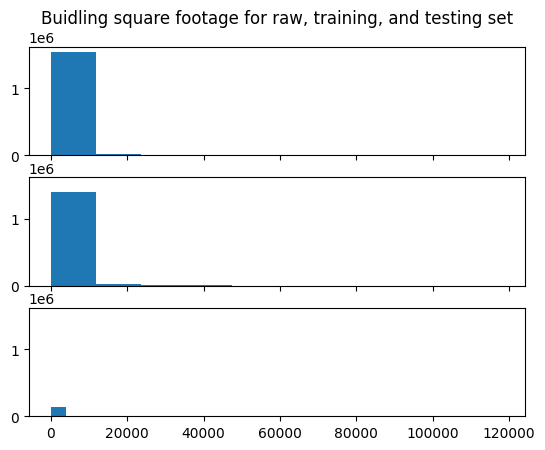

In [12]:
fig, axes = plt.subplots(3, sharex=True, sharey=True)
axes.flatten()[0].hist(dat["sqmeters"])
axes.flatten()[1].hist(tr["sqmeters"])
axes.flatten()[2].hist(test["sqmeters"])
axes.flatten()[0].set_title(
    "Buidling square footage for raw, training, and testing set"
)
fig.show()

In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') 
# device = torch.device('cpu')

x_sin_hod = torch.tensor(tr["sin_hod"].values, dtype=torch.float32).unsqueeze(1).to(device)
x_cos_hod = torch.tensor(tr["cos_hod"].values, dtype=torch.float32).unsqueeze(1).to(device)
x_area = torch.tensor(tr["sqmeters_scaled"].values, dtype=torch.float32).unsqueeze(1).to(device)
x_sin_dow = torch.tensor(tr["sin_dow"].values, dtype=torch.float32).unsqueeze(1).to(device)
x_cos_dow = torch.tensor(tr["cos_dow"].values, dtype=torch.float32).unsqueeze(1).to(device)
x_type = torch.tensor(tr["x_prim_occ"].values, dtype=torch.long).to(device)

y = torch.tensor(y_tr.values, dtype=torch.float32).unsqueeze(1).to(device)


# Training


In [14]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()

        input_size = 5 + 5
        hidden_size = 32
        output_size = 1

        self.type_emb = nn.Embedding(n_cats, 5)

        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            # nn.Linear(hidden_size, hidden_size),
            # nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size),
        )

    def forward(self, x_sin_hod, x_cos_hod, x_area, x_sin_dow, x_cos_dow, x_type):
        x_type_emb = self.type_emb(x_type)
        x = torch.cat(
            [x_sin_hod, x_cos_hod, x_area, x_sin_dow, x_cos_dow, x_type_emb], dim=1
        )
        return self.net(x)

In [15]:
loss_fn = nn.PoissonNLLLoss(log_input=True)

In [16]:
n_learners = 1
num_epochs = 2000
boost_lr = 0.1

learners = []

for m in range(n_learners):

    print(f"\nTraining learner {m+1}/{n_learners}")

    model = Net().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=5)

    # Freeze previous learners
    for mdl in learners:
        mdl.eval()
        for p in mdl.parameters():
            p.requires_grad_(False)

    # Compute previous ensemble log-rate
    with torch.no_grad():
        if learners:
            prev_log_rate = learners[0](
                x_sin_hod, x_cos_hod, x_area, x_sin_dow, x_cos_dow, x_type
            ) + sum(boost_lr * mdl(x_sin_hod, x_cos_hod, x_area, x_sin_dow, x_cos_dow, x_type)
                for mdl in learners[1:])
        else:
            prev_log_rate = torch.zeros_like(y)

    for epoch in range(num_epochs):

        model.train()
        optimizer.zero_grad()

        current_log_rate = model(x_sin_hod, x_cos_hod, x_area, x_sin_dow, x_cos_dow, x_type)

        if not learners:
            ensemble_log_rate = current_log_rate
        else:
            ensemble_log_rate = prev_log_rate + boost_lr * current_log_rate

        loss = loss_fn(ensemble_log_rate, y)

        loss.backward()
        optimizer.step()

        if epoch % 50 == 0:
            print(f"Epoch {epoch:4d} | Loss = {loss.item():.6f}")

    model.eval()
    learners.append(model)


Training learner 1/1
Epoch    0 | Loss = 0.989108
Epoch   50 | Loss = 0.537368
Epoch  100 | Loss = 0.478645
Epoch  150 | Loss = 0.448709
Epoch  200 | Loss = 0.423298
Epoch  250 | Loss = 0.390506
Epoch  300 | Loss = 0.363128
Epoch  350 | Loss = 0.356853
Epoch  400 | Loss = 0.353322
Epoch  450 | Loss = 0.350039
Epoch  500 | Loss = 0.347520
Epoch  550 | Loss = 0.345729
Epoch  600 | Loss = 0.344211
Epoch  650 | Loss = 0.342892
Epoch  700 | Loss = 0.341455
Epoch  750 | Loss = 0.339951
Epoch  800 | Loss = 0.338361
Epoch  850 | Loss = 0.336723
Epoch  900 | Loss = 0.335149
Epoch  950 | Loss = 0.333610
Epoch 1000 | Loss = 0.332172
Epoch 1050 | Loss = 0.330836
Epoch 1100 | Loss = 0.329460
Epoch 1150 | Loss = 0.328065
Epoch 1200 | Loss = 0.326741
Epoch 1250 | Loss = 0.325220
Epoch 1300 | Loss = 0.324087
Epoch 1350 | Loss = 0.323082
Epoch 1400 | Loss = 0.322155
Epoch 1450 | Loss = 0.321463
Epoch 1500 | Loss = 0.320942
Epoch 1550 | Loss = 0.320507
Epoch 1600 | Loss = 0.320156
Epoch 1650 | Loss = 0

In [17]:


loss_fn = nn.PoissonNLLLoss(log_input=True)

for run in range(10):

    model = Net().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(2000):

        optimizer.zero_grad()

        log_rate = model(
            x_sin_hod,
            x_cos_hod,
            x_area,
            x_sin_dow,
            x_cos_dow,
            x_type,
        )

        loss = loss_fn(log_rate, y)

        loss.backward()
        optimizer.step()

    print(f"Run {run + 1}: {loss.item():.6f}")

Run 1: 0.318231
Run 2: 0.316536
Run 3: 0.317562
Run 4: 0.317573
Run 5: 0.318722
Run 6: 0.318169
Run 7: 0.318185
Run 8: 0.316438
Run 9: 0.318328
Run 10: 0.318454


# Validation

In [18]:
for mdl in learners:
    mdl.eval()
    
x_sin_hod = (
    torch.tensor(test["sin_hod"].values, dtype=torch.float32).unsqueeze(1).to(device)
)
x_cos_hod = (
    torch.tensor(test["cos_hod"].values, dtype=torch.float32).unsqueeze(1).to(device)
)
x_area = (
    torch.tensor(test["log_sqmeters"].values, dtype=torch.float32)
    .unsqueeze(1)
    .to(device)
)
x_sin_dow = (
    torch.tensor(test["sin_dow"].values, dtype=torch.float32).unsqueeze(1).to(device)
)
x_cos_dow = (
    torch.tensor(test["cos_dow"].values, dtype=torch.float32).unsqueeze(1).to(device)
)
x_type = torch.tensor(test["x_prim_occ"].values, dtype=torch.long).to(device)

y = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)


with torch.no_grad():

    ensemble_log_rate = learners[0](
        x_sin_hod, x_cos_hod, x_area, x_sin_dow, x_cos_dow, x_type
    ) + sum(
        boost_lr
        * mdl(x_sin_hod, x_cos_hod,
            x_area,
            x_sin_dow,
            x_cos_dow,
            x_type,
        )
        for mdl in learners[1:]
    )

    pred = torch.exp(ensemble_log_rate).cpu().squeeze()
    obs = y.detach().cpu().squeeze().numpy()

df_pred = pd.DataFrame(
    {
        "build_id": test["build_id"],
        "type": test["prim_occ"],
        "day_w": test["day_w"],
        "hour_d": test["hour_d"],
        "sq_q": test["sq_q"],
        "pred": pred,
        "obs": obs,
    }
)

df_grp = (
    df_pred.groupby(["type", "day_w", "hour_d"], observed=True)[["pred", "obs"]]
    .mean()
    .reset_index()
)


known_categories = set(tr["prim_occ"].unique())

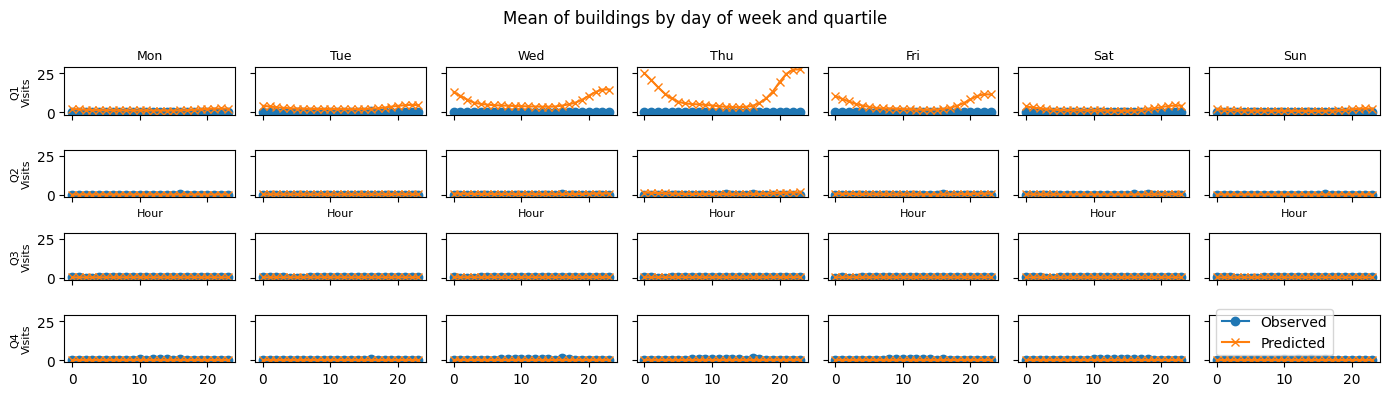

In [19]:
# Parameters
quartiles = [0, 1, 2, 3]  # Q1 and Q4
dow = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
days = [0, 1, 2, 3, 4, 5, 6]

# Set up plot grid: 2 rows (Q1 and Q4), 7 columns (days)
fig, axes = plt.subplots(4, 7, figsize=(14, 4), sharex=True, sharey=True)
axes = np.atleast_2d(axes)

for row, q in enumerate(quartiles):
    for col, day in enumerate(days):
        ax = axes[row, col]
        mask = (df_pred["day_w"] == day) & (df_pred["sq_q"] == q)
        sub = df_pred[mask]

        if not sub.empty:
            grp = sub.groupby("hour_d", observed=True)[["obs", "pred"]].mean()
            ax.plot(grp.index, grp["obs"], marker="o", label="Observed")
            ax.plot(grp.index, grp["pred"], marker="x", label="Predicted")

        if col == 0:
            ax.set_ylabel(f"Q{q+1}\nVisits", fontsize=8)
        if row == 1:
            ax.set_xlabel("Hour", fontsize=8)
        if row == 0:
            ax.set_title(dow[day], fontsize=9)

fig.suptitle("Mean of buildings by day of week and quartile")
plt.tight_layout()
plt.legend()
plt.show()

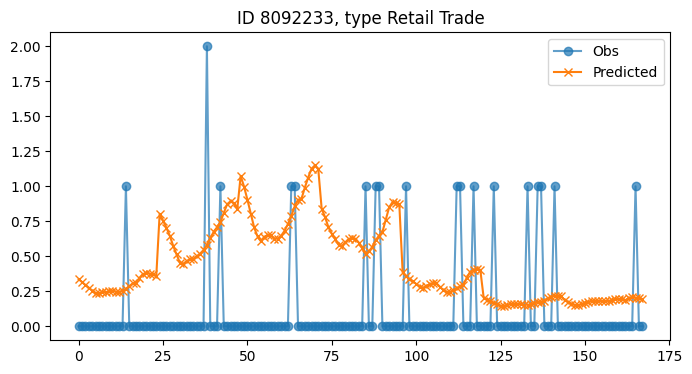

In [20]:
test_builds = df_pred["build_id"].unique()
rand = np.random.default_rng()

build = rand.choice(test_builds)
build_preds = df_pred[df_pred["build_id"] == build]
build_preds["hour_w"] = build_preds["day_w"] * 24 + build_preds["hour_d"]

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(build_preds["hour_w"], build_preds["obs"], marker="o", alpha=0.7, label="Obs")
ax.plot(build_preds["hour_w"], build_preds["pred"], marker="x", label="Predicted")

plt.title(f"ID {build_preds['build_id'].iloc[0]}, type {build_preds['type'].iloc[0]}")
plt.legend()

In [21]:
# confirm no leakage of test data into train
print(tr[tr["build_id"] == 1308986])
print(tr[tr["build_id"] == '1308986'])

Empty DataFrame
Columns: [build_id, occ_cls, prim_occ, sqmeters, sqfeet, censuscode, uuid, safegraph_place_id, date_range_start, t, hour_of_week, hour_d, sin_hod, cos_hod, day_w, sin_dow, cos_dow, sqmeters_scaled, log_sqmeters, sq_q, x_prim_occ]
Index: []

[0 rows x 21 columns]
Empty DataFrame
Columns: [build_id, occ_cls, prim_occ, sqmeters, sqfeet, censuscode, uuid, safegraph_place_id, date_range_start, t, hour_of_week, hour_d, sin_hod, cos_hod, day_w, sin_dow, cos_dow, sqmeters_scaled, log_sqmeters, sq_q, x_prim_occ]
Index: []

[0 rows x 21 columns]


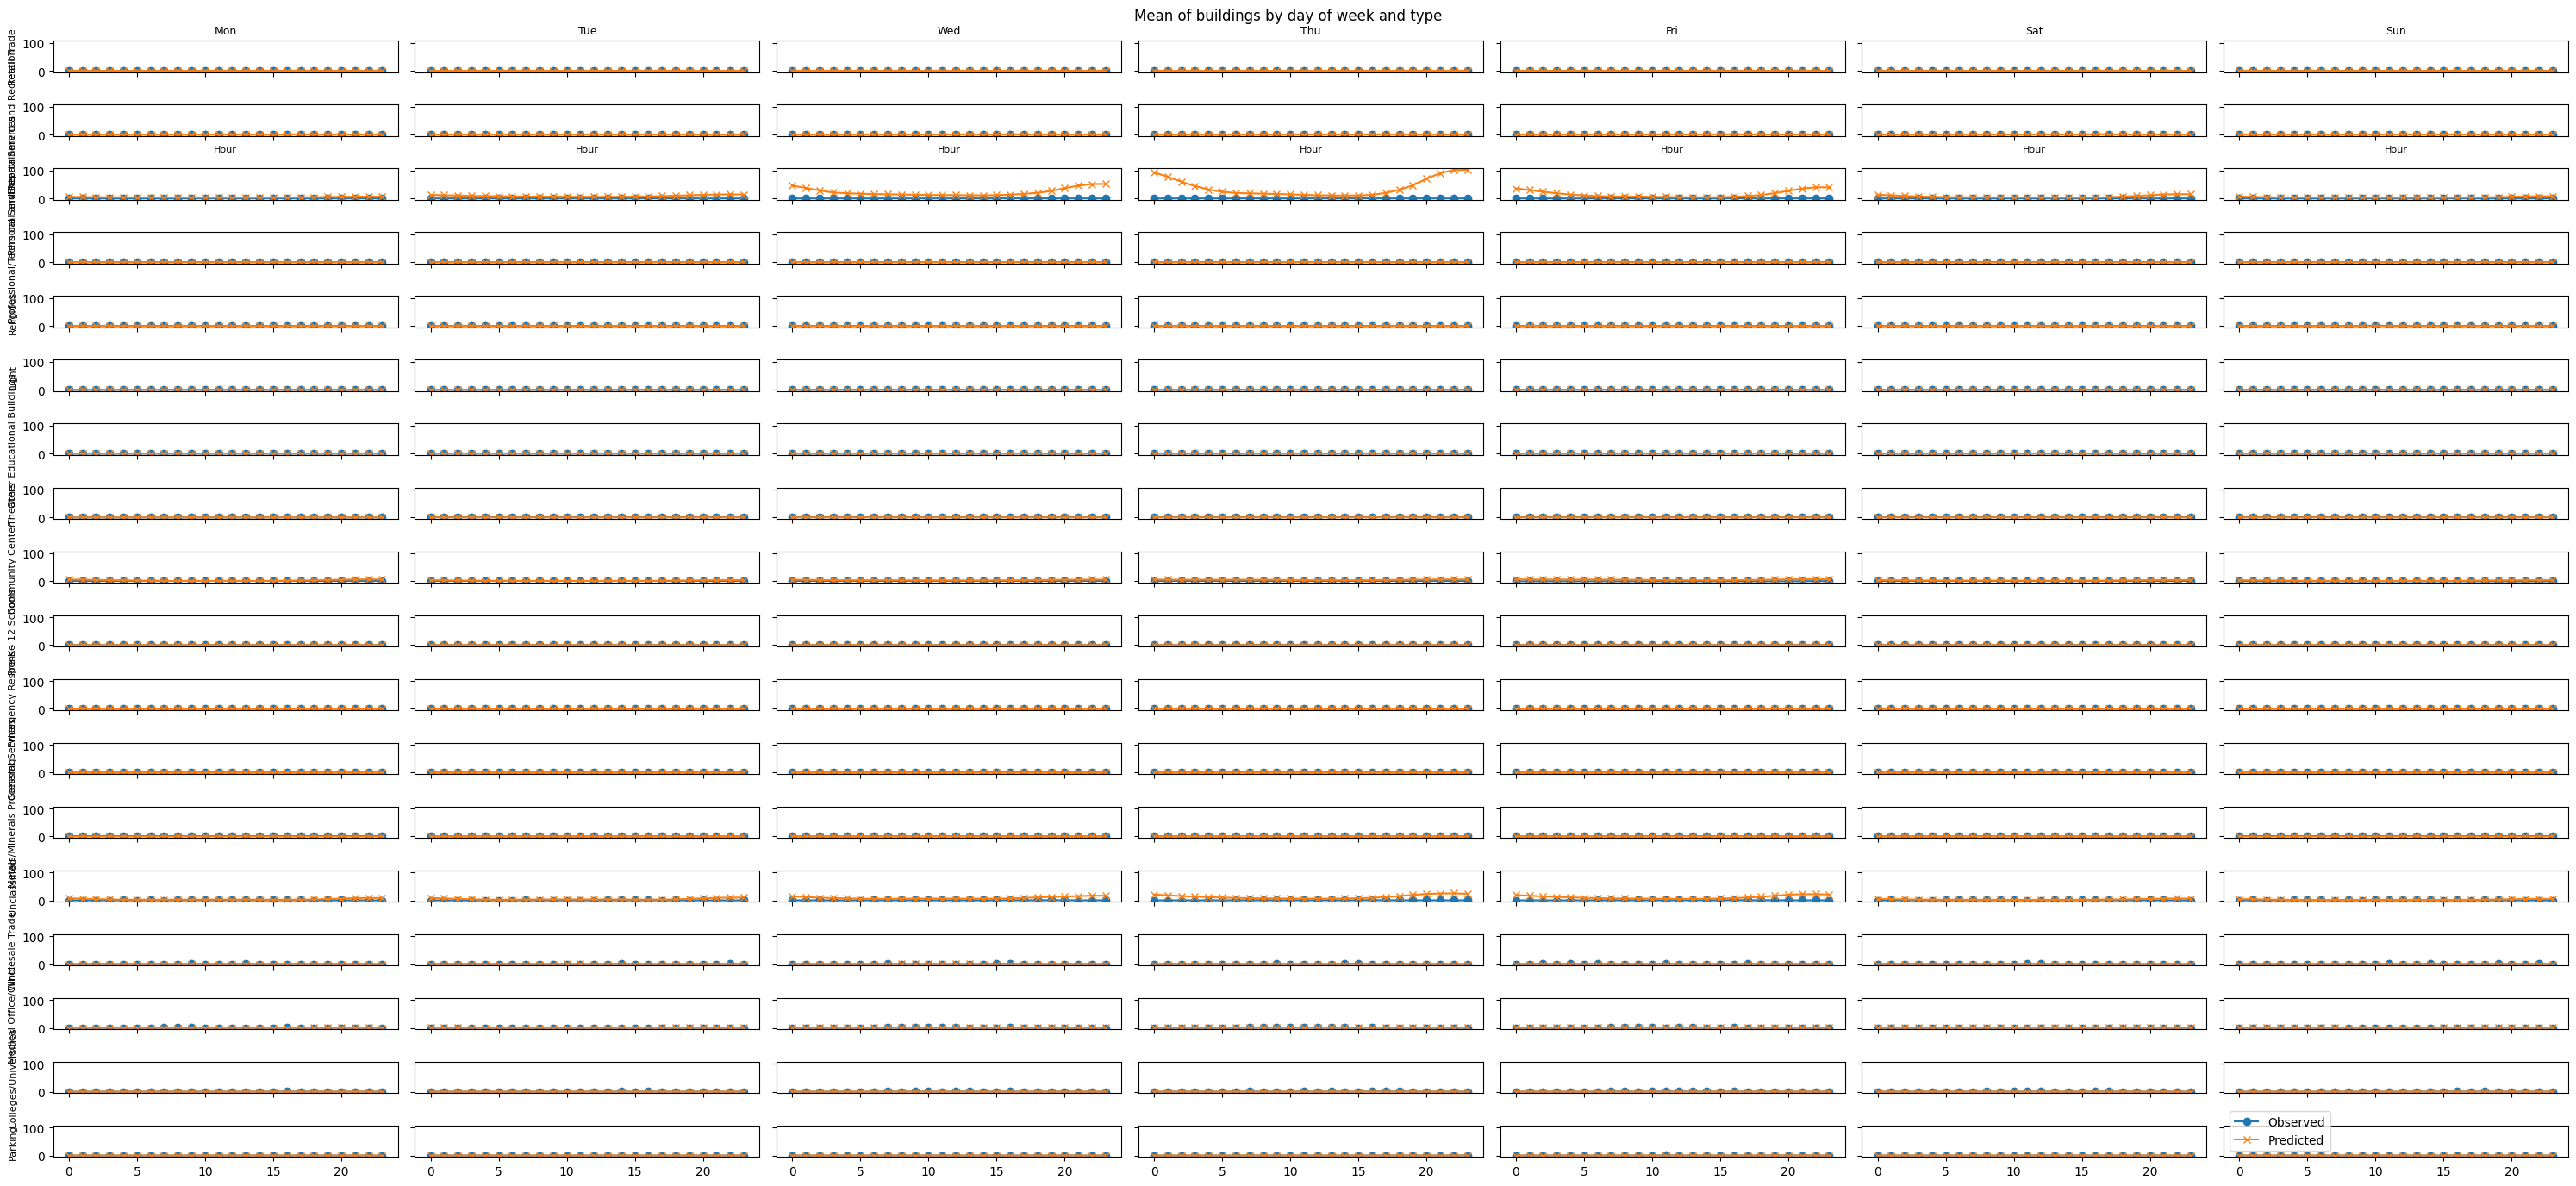

In [22]:
# Parameters
categories = df_pred["type"].unique()
n_cats = len(categories)
dow = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
days = [0, 1, 2, 3, 4, 5, 6]

# Set up plot grid: 2 rows (Q1 and Q4), 7 columns (days)
fig, axes = plt.subplots(n_cats, 7, figsize=(30, 14), sharex=True, sharey=True)
axes = np.atleast_2d(axes)

for row, q in enumerate(categories):
    for col, day in enumerate(days):
        ax = axes[row, col]
        mask = (df_pred["day_w"] == day) & (df_pred["type"] == q)
        sub = df_pred[mask]

        if not sub.empty:
            grp = sub.groupby("hour_d", observed=True)[["obs", "pred"]].mean()
            ax.plot(grp.index, grp["obs"], marker="o", label="Observed")
            ax.plot(grp.index, grp["pred"], marker="x", label="Predicted")

        if col == 0:
            ax.set_ylabel(f"{q}", fontsize=8)
        if row == 1:
            ax.set_xlabel("Hour", fontsize=8)
        if row == 0:
            ax.set_title(dow[day], fontsize=9)

fig.suptitle("Mean of buildings by day of week and type")
plt.tight_layout()
plt.legend()
plt.show()

In [23]:
df_pred = pd.DataFrame(
    {
        "build_id": test["build_id"],
        "type": test["prim_occ"],
        "day_w": test["day_w"],
        "hour_d": test["hour_d"],
        "sq_q": test["sq_q"],
        "pred": pred,
        "obs": obs,
    }
)

df_grp = (
    df_pred.groupby(["type", "day_w", "hour_d"], observed=True)[["pred", "obs"]]
    .mean()
    .reset_index()
)


known_categories = set(tr["prim_occ"].unique())

Text(0.5, 1.0, 'pred vs obs')

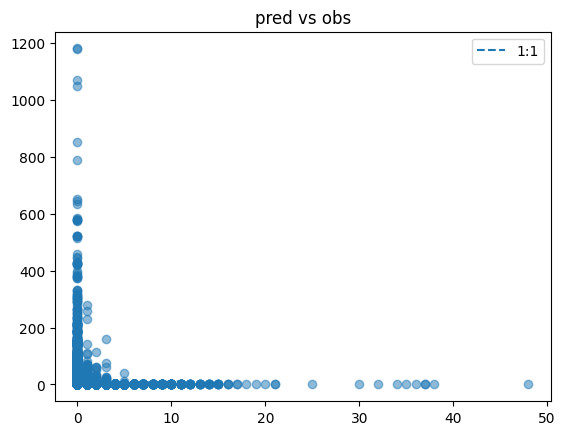

In [24]:
plt.scatter(df_pred["obs"], df_pred["pred"], alpha=0.5)
plt.plot([0, 12], [0, 12], linestyle="--", label="1:1")
plt.legend()
plt.title("pred vs obs")

In [25]:
torch.save(model.state_dict(), 'model_weights.pth')

# Adding noise (may not need due to variability in neural network)

In [26]:
cpu_rng_state = torch.get_rng_state()
print(*cpu_rng_state.cpu().squeeze().numpy())

31 116 97 140 28 215 32 153 181 0 0 0 1 0 0 0 188 1 0 0 0 0 0 0 148 82 108 81 0 0 0 0 72 64 213 247 0 0 0 0 98 64 110 248 0 0 0 0 13 10 66 94 0 0 0 0 237 144 74 187 0 0 0 0 79 29 199 211 0 0 0 0 169 233 29 207 0 0 0 0 191 253 138 72 0 0 0 0 54 136 221 230 0 0 0 0 253 105 124 130 0 0 0 0 82 241 126 92 0 0 0 0 2 222 186 82 0 0 0 0 58 211 212 34 0 0 0 0 181 89 252 142 0 0 0 0 201 51 195 76 0 0 0 0 34 81 122 245 0 0 0 0 249 11 163 16 0 0 0 0 229 93 240 166 0 0 0 0 75 99 200 3 0 0 0 0 229 205 6 235 0 0 0 0 243 34 133 190 0 0 0 0 160 57 8 215 0 0 0 0 187 84 170 170 0 0 0 0 174 138 100 168 0 0 0 0 176 78 253 8 0 0 0 0 158 47 233 52 0 0 0 0 106 168 30 69 0 0 0 0 232 97 232 167 0 0 0 0 135 70 189 12 0 0 0 0 195 11 22 172 0 0 0 0 222 71 50 202 0 0 0 0 208 138 90 225 0 0 0 0 15 174 65 0 0 0 0 0 224 174 67 150 0 0 0 0 140 5 150 2 0 0 0 0 173 10 58 165 0 0 0 0 57 65 48 142 0 0 0 0 0 212 172 166 0 0 0 0 84 21 146 210 0 0 0 0 66 81 234 88 0 0 0 0 185 25 108 129 0 0 0 0 146 177 198 146 0 0 0 0 142 44 

In [27]:
df_pred["hour_w"] = df_pred["day_w"] * 24 + df_pred["hour_d"]
df_pred["simulated"] = np.random.poisson(df_pred["pred"])
pred_wide = df_pred.pivot(index="build_id", columns="hour_w", values="simulated")

ValueError: Index contains duplicate entries, cannot reshape

In [ ]:
plt.figure(figsize=(12, 6))
sns.heatmap(pred_wide, cmap="viridis", cbar=True)

plt.xlabel("Hour")
plt.ylabel("Entity")
plt.title("Visits per Hour with Poisson noise")
plt.tight_layout()
plt.show()

In [ ]:
nonres = df[df["occ_cls"] != "Residential"][pd.isna(df["sg_match"])]

nonres = nonres.melt(
    id_vars=["prim_occ", "sqmeters", "build_id"],
    value_vars=visits_cols,
    var_name="hour_of_week",
    value_name="visits",
)

nonres["prim_occ"] = nonres["prim_occ"].where(
    nonres["prim_occ"].isin(known_categories), "Unclassified"
)

nonres["hour_of_week"] = nonres["hour_of_week"].str.extract(r"(\d+)").astype(int)
nonres["hour_d"] = nonres["hour_of_week"] % 24  # 0-23
nonres["sin_hod"] = np.sin(2 * np.pi * nonres["hour_d"] / 24)
nonres["cos_hod"] = np.cos(2 * np.pi * nonres["hour_d"] / 24)


nonres["day_w"] = nonres["hour_of_week"] // 24  # 0-6
nonres["sin_dow"] = np.sin(2 * np.pi * nonres["day_w"] / 7)
nonres["cos_dow"] = np.cos(2 * np.pi * nonres["day_w"] / 7)

nonres["sqmeters"] = pd.to_numeric(nonres["sqmeters"], errors="coerce")
nonres["sqmeters_scaled"] = nonres["sqmeters"] / nonres["sqmeters"].max()
nonres["log_sqmeters"] = np.log(nonres["sqmeters"])


nonres["x_prim_occ"] = nonres["prim_occ"].astype("category").cat.codes
nonres

In [ ]:
z_sin_hod = (
    torch.tensor(nonres["sin_hod"].values, dtype=torch.float32).unsqueeze(1).to(device)
)
z_cos_hod = (
    torch.tensor(nonres["cos_hod"].values, dtype=torch.float32).unsqueeze(1).to(device)
)
# z_area = torch.tensor(nonres['sqmeters_scaled'].values, dtype=torch.float32).unsqueeze(1).to(device)
z_area = (
    torch.tensor(nonres["log_sqmeters"].values, dtype=torch.float32)
    .unsqueeze(1)
    .to(device)
)
z_sin_dow = (
    torch.tensor(nonres["sin_dow"].values, dtype=torch.float32).unsqueeze(1).to(device)
)
z_cos_dow = (
    torch.tensor(nonres["cos_dow"].values, dtype=torch.float32).unsqueeze(1).to(device)
)
z_type = torch.tensor(nonres["x_prim_occ"].values, dtype=torch.long).to(device)

In [ ]:
fill = (
    model(z_sin_hod, z_cos_hod, z_area, z_sin_dow, z_cos_dow, z_type)
    .detach()
    .cpu()
    .squeeze()
    .numpy()
)
df_pred = pd.DataFrame(
    {
        "build_id": nonres["build_id"],
        "type": nonres["prim_occ"],
        "day_w": nonres["day_w"],
        "hour_d": nonres["hour_d"],
        "sq": nonres["sqmeters"],
        "pred": fill,
    }
)

df_pred["hour_w"] = df_pred["day_w"] * 24 + df_pred["hour_d"]
pred_wide = df_pred.pivot(index="build_id", columns="hour_w", values="pred")

In [ ]:
# Heatmap of raw data
plt.figure(figsize=(12, 6))
sns.heatmap(pred_wide, cmap="viridis", cbar=True, vmax=12)

plt.xlabel("Hour")
plt.ylabel("Entity")
plt.title("Modeled visits per hour")
plt.tight_layout()
plt.show()

In [ ]:
df_pred

In [ ]:
torch.save(model.state_dict(), "model_weights.pth")